## RED NEURONAL CONVOLUCIONAL

En este notebook implementaremos una **Red Neuronal Convoluciona (CNN)**. Esta arquitectura aprovecha la jerarquía espacial de las imágenes de Fashion-MNIST mediante una capa convolucional y la operación *Global Average Pooling (GAP).*

In [9]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.datasets import fashion_mnist
from model import build_conv_minimal # Importamos desde model.py

# 1. Carga de datos
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# 2. Preprocesamiento: Normalización y Reshape para CNN (28, 28, 1)
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. División de datos (Entrenamiento, Validación, Test)
X, X_val, y, y_val = train_test_split(X_train_full, y_train_full,
                                      test_size=0.2, random_state=42,
                                      stratify=y_train_full)

print(f"X (Train): {X.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X (Train): (48000, 28, 28, 1), X_val: (12000, 28, 28, 1), X_test: (10000, 28, 28, 1)


##2. Definición del Modelo CNN

Diseñaremos una arquitectura basada en Redes Neuronales Convolucionales (CNN) siguiendo el principio de mínima complejidad. La convolución utiliza filtros locales que permiten capturar patrones espaciales y texturas, elementos clave en imágenes de prendas de ropa.

La arquitectura propuesta es un ejercicio de eficiencia extrema que utiliza:

1. **Capa Convolucional:** Con kernels de $3 \times 3$ para extraer rasgos característicos (bordes, uniones, tramas).
2. **Activación ReLU:** Para introducir la no linealidad necesaria que permite distinguir formas complejas.
3. **Global Average Pooling (GAP):** En lugar de aplanar la imagen y usar capas densas (que dispararían el número de parámetros), el GAP reduce cada mapa de características a su promedio, conectando directamente con la salida.



In [10]:
'''
import tensorflow as tf
from tensorflow.keras import layers, models

def build_conv_minimal(input_shape=(28, 28, 1), num_classes=10):
    """
    Arquitectura CNN Evolucionada:
    - Dos capas convolucionales para ganar profundidad.
    - Global Average Pooling para mantener los parámetros bajos.
    """
    model = models.Sequential([
        # Capa 1: Extrae rasgos básicos (bordes)
        layers.Conv2D(filters=16, kernel_size=(3, 3), padding='same',
                      activation='relu', input_shape=input_shape),

        # Capa 2: Combina rasgos (formas). 10 filtros porque hay 10 clases.
        layers.Conv2D(filters=num_classes, kernel_size=(3, 3),
                      padding='same', activation='relu'),

        # Global Average Pooling
        layers.GlobalAveragePooling2D(),

        layers.Activation('softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

'''

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 10)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1045 - loss: 2.2804 - val_accuracy: 0.1477 - val_loss: 2.2367
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1596 - loss: 2.2265 - val_accuracy: 0.2021 - val_loss: 2.1964
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1894 - loss: 2.1895 - val_accuracy: 0.2139 - val_loss: 2.1624
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.2025 - loss: 2.1557 - val_accuracy: 0.2128 - val_loss: 2.1350
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2005 - loss: 2.1307 - val_accuracy: 0.2140 - val_loss: 2.1108
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2112 - loss: 2.1059 - val_accuracy: 0.2393 - val_loss: 2.0894
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2413 - loss: 2.0876 - val_accuracy: 0.2713 - val_loss: 2.0706
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2705 - loss: 2.0645 - val_a

## 3. Entrenamiento

Entrenamos el modelo y visualizamos las curvas de aprendizaje.

In [11]:
# Instanciamos el modelo de model.py
model = build_conv_minimal()
model.summary()

# Entrenamiento
history = model.fit(X, y,
                    epochs=50,
                    batch_size=64,
                    validation_data=(X_val, y_val),
                    verbose=1)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 10)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1168 - loss: 2.2859 - val_accuracy: 0.1745 - val_loss: 2.2453
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1840 - loss: 2.2280 - val_accuracy: 0.2232 - val_loss: 2.1876
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2308 - loss: 2.1771 - val_accuracy: 0.2470 - val_loss: 2.1489
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.2574 - loss: 2.1393 - val_accuracy: 0.2772 - val_loss: 2.1182
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2723 - loss: 2.1116 - val_accuracy: 0.2838 - val_loss: 2.0925
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2858 - loss: 2.0859 - val_accuracy: 0.2819 - val_loss: 2.0709
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2742 - loss: 2.0689 - val_accuracy: 0.2923 - val_loss: 2.0523
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2857 - loss: 2.0515 - val_acc

## 4. Matriz de Confusión

Visualizamos dónde se confunde el modelo utilizando el conjunto de test.

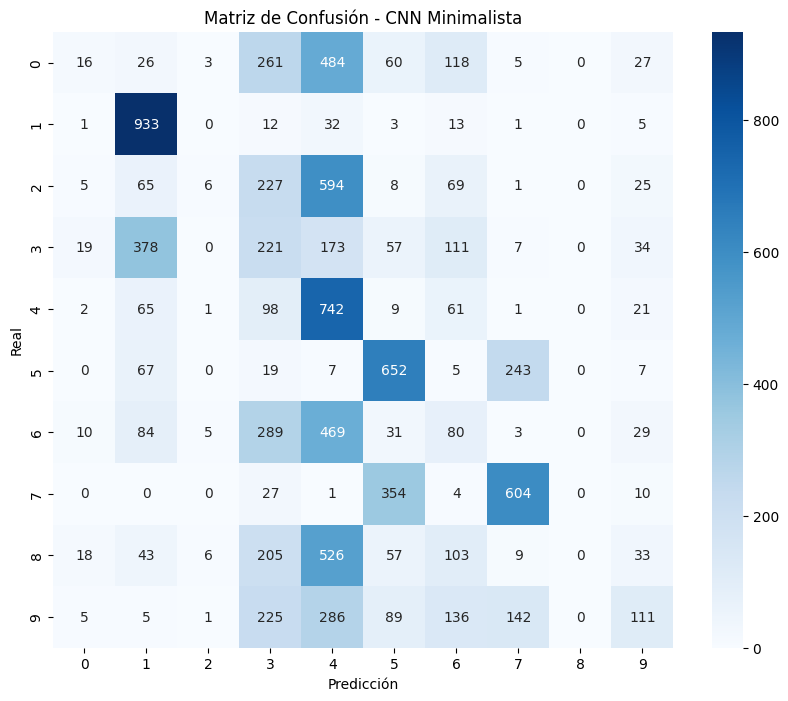

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - CNN Minimalista')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## 5. Evaluación Final

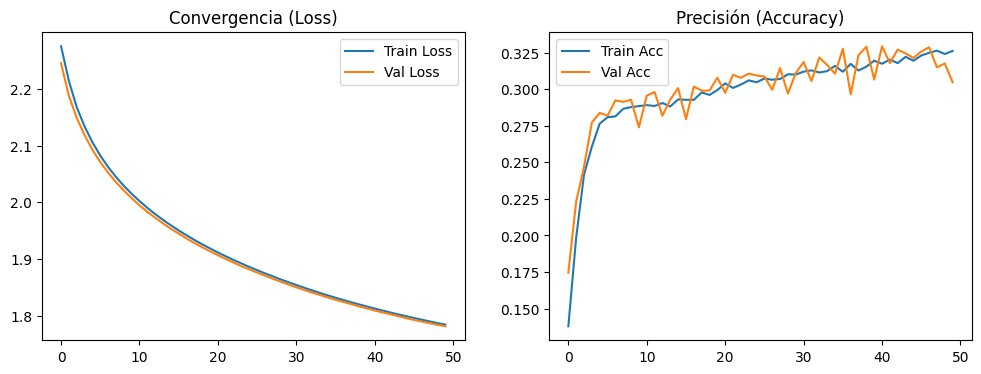

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- RESULTADOS FINALES ---
Train Acc: 0.3261 | Val Acc: 0.3047 | Test Acc: 0.3138
Parámetros: 100


In [13]:
# Curvas de Aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Convergencia (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Precisión (Accuracy)')
plt.legend()
plt.show()

# Evaluación en Test
y_pred = np.argmax(model.predict(X_test), axis=1)
test_acc = accuracy_score(y_test, y_pred)
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\n--- RESULTADOS FINALES ---")
print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")
print(f"Parámetros: {model.count_params()}")

## Resumen de Resultados - MLP

| Modelo | Parámetros |Train Acc | Val Acc | Test Acc
| :--- | :---: | :---: | :---: |:--- |
| **MLP** | 6370 | 0.8761 | 0.8573 |0.8866 | 0.8462

### Análisis del Modelo MLP y Comparativa

El **Perceptrón Multicapa (MLP)** representa un salto significativo respecto al modelo lineal.



Al contar con apenas 6,370 parámetros y una única capa oculta de 8 neuronas con activación ReLU, el modelo es capaz de comprimir la información en un espacio latente de muy baja dimensión sin sacrificar excesiva precisión. Esto se traduce en una capacidad de generalización notable, alcanzando un 84.62% de accuracy en el conjunto de test.

Es fascinante observar que, en este dataset, este MLP ultra-ligero logra resultados competitivos utilizando una fracción ínfima de la capacidad de cómputo de modelos más robustos. Esto sugiere que la estructura fundamental de las prendas en Fashion-MNIST puede ser capturada mediante una arquitectura extremadamente simple, siempre que se introduzca la no-linealidad:

Aunque los resultados en entrenamiento (87.61%) y validación (85.73%) muestran una convergencia excelente y una brecha mínima (evitando por completo el overfitting), el modelo alcanza aquí su techo de aprendizaje.

Nuestro principal reto sigue siendo la clasificación de las clases visualmente solapadas. Al haber forzado un "cuello de botella" de solo 8 neuronas, el modelo prioriza las siluetas generales, lo que dificulta la distinción de detalles finos necesarios para diferenciar, por ejemplo, 'Shirt' de 'Coat'. Para superar este umbral, el siguiente paso lógico será aumentar ligeramente la capacidad o evolucionar hacia arquitecturas convolucionales que exploten la jerarquía espacial de los píxeles.
